# 2. 网格降雨数据处理与流域面平均计算

本节将演示如何使用**面积占比法**处理网格降雨数据，计算流域面平均降雨量。

## 方法说明
- **数据源**: 
  - MSWEP: 使用 Daily 文件夹下的真实数据（2021年）
  - GFS: 使用2024年数据
- **计算方法**: 面积占比法（Grid Area-Weighted Method）
- **示例**: 使用1个流域，2021年全年数据

## 1. 导入必要的库

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point, Polygon, box
from datetime import datetime, timedelta
import glob
import os
import time
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")

所有库导入成功！


## 2. 加载流域数据

从 shapefile 中选择一个示例流域进行演示。

In [3]:
# 读取流域 shapefile
shapefile_path = "/home/zlh/data/googleflood/shapes/basins.shp"
basins_gdf = gpd.read_file(shapefile_path)

print(f"流域总数: {len(basins_gdf)}")
print(f"\n流域数据字段: {list(basins_gdf.columns)}")
print(f"\n前3个流域信息:")
print(basins_gdf[['BASIN_ID', 'AREA']].head(3))

流域总数: 5819

流域数据字段: ['BASIN_ID', 'AREA', 'geometry']

前3个流域信息:
          BASIN_ID          AREA
0   anhui_62909400    497.103823
1  changdian_60650  14818.479819
2  changdian_60668   4481.930930


In [5]:
# 选择一个示例流域（选择中等面积的流域）
# 这里选择第100个流域作为示例
example_basin = basins_gdf.iloc[100:101].copy()
basin_id = example_basin['BASIN_ID'].values[0]
basin_area = example_basin['AREA'].values[0]

print(f"示例流域信息:")
print(f"  BASIN_ID: {basin_id}")
print(f"  流域面积: {basin_area:.2f} km²")
print(f"  流域边界: {example_basin.total_bounds}")

# 获取流域几何对象
basin_geom = example_basin.geometry.values[0]

示例流域信息:
  BASIN_ID: songliao_11602050
  流域面积: 53971.20 km²
  流域边界: [124.72499999  40.17250001 128.76499999  42.28750001]


## 3. 加载 MSWEP 真实数据

从 Daily 文件夹加载 2021 年的 MSWEP 日降雨数据。

In [7]:
def load_mswep_data(data_dir, year, basin_bounds):
    """
    加载 MSWEP 数据并裁剪到流域范围
    
    参数:
        data_dir: 数据目录
        year: 年份
        basin_bounds: 流域边界 [minx, miny, maxx, maxy]
    
    返回:
        xarray.Dataset
    """
    # 查找该年份的所有文件
    pattern = os.path.join(data_dir, f"{year}*.nc")
    files = sorted(glob.glob(pattern))
    
    print(f"找到 {len(files)} 个 MSWEP 文件 ({year}年)")
    
    if len(files) == 0:
        raise FileNotFoundError(f"未找到 {year} 年的 MSWEP 数据")
    
    # 扩展边界以确保完全覆盖流域
    minx, miny, maxx, maxy = basin_bounds
    margin = 0.5  # 0.5度边界
    minx -= margin
    miny -= margin
    maxx += margin
    maxy += margin
    
    # 读取并合并所有文件
    datasets = []
    
    print("正在加载数据...")
    for i, file in enumerate(files):
        if (i + 1) % 50 == 0:
            print(f"  已加载 {i+1}/{len(files)} 个文件...")
        
        try:
            ds = xr.open_dataset(file)
            
            # 检查坐标名称（可能是 lat/lon 或 latitude/longitude）
            lat_name = 'lat' if 'lat' in ds.coords else 'latitude'
            lon_name = 'lon' if 'lon' in ds.coords else 'longitude'
            
            # 检查经度范围（0-360 或 -180-180）
            lon_values = ds[lon_name].values
            query_minx, query_maxx = minx, maxx
            if lon_values.min() >= 0 and lon_values.max() > 180:
                # 经度是 0-360 格式，需要转换查询范围
                if query_minx < 0:
                    query_minx += 360
                if query_maxx < 0:
                    query_maxx += 360
            
            # 检查纬度排序方向
            lat_values = ds[lat_name].values
            if lat_values[0] > lat_values[-1]:
                # 纬度是降序（从北到南）
                lat_slice = slice(maxy, miny)
            else:
                # 纬度是升序（从南到北）
                lat_slice = slice(miny, maxy)
            
            # 裁剪到流域范围
            ds_cropped = ds.sel(
                {lat_name: lat_slice,
                 lon_name: slice(query_minx, query_maxx)}
            )
            
            # 检查裁剪后是否有数据
            if ds_cropped[lat_name].size == 0 or ds_cropped[lon_name].size == 0:
                print(f"警告: 文件 {os.path.basename(file)} 裁剪后无数据")
                continue
            
            datasets.append(ds_cropped)
            
        except Exception as e:
            print(f"警告: 加载文件 {file} 失败: {e}")
            continue
    
    if len(datasets) == 0:
        raise ValueError(
            f"所有文件裁剪后都无数据。请检查:\n"
            f"  1. 流域边界 [{minx:.2f}, {miny:.2f}, {maxx:.2f}, {maxy:.2f}]\n"
            f"  2. MSWEP 数据的空间范围是否覆盖该流域"
        )
    
    print(f"成功加载 {len(datasets)} 个文件")
    
    # 合并所有时间步
    print("正在合并数据...")
    combined = xr.concat(datasets, dim='time')
    
    # 标准化坐标名称
    if 'latitude' in combined.coords:
        combined = combined.rename({'latitude': 'lat', 'longitude': 'lon'})
    
    # 检查降水变量名称（可能是 precipitation 或 precip）
    precip_var = None
    for var_name in ['precipitation', 'precip', 'pr', 'rainfall']:
        if var_name in combined.data_vars:
            precip_var = var_name
            break
    
    if precip_var is None:
        raise ValueError(f"未找到降水变量，可用变量: {list(combined.data_vars)}")
    
    # 如果变量名不是 precipitation，重命名
    if precip_var != 'precipitation':
        combined = combined.rename({precip_var: 'precipitation'})
    
    combined.attrs['description'] = f'MSWEP daily precipitation {year}'
    combined.attrs['units'] = 'mm/day'
    
    return combined

# 加载 MSWEP 数据
print("加载 MSWEP 真实数据 (2021年)...")
start_time = time.time()

data_dir = "/home/zlh/data/MSWEP/Daily" # 替换成你的MSWEP路径
year = 2021 # 替换成你的数据年份

try:
    mswep_data = load_mswep_data(
        data_dir=data_dir,
        year=year,
        basin_bounds=example_basin.total_bounds
    )
    mswep_load_time = time.time() - start_time
    
    print(f"\nMSWEP 数据加载成功！")
    print(f"  数据形状: {mswep_data.precipitation.shape}")
    print(f"  时间点数: {len(mswep_data.time)}")
    print(f"  空间范围: lat [{mswep_data.lat.min().values:.2f}, {mswep_data.lat.max().values:.2f}]")
    print(f"            lon [{mswep_data.lon.min().values:.2f}, {mswep_data.lon.max().values:.2f}]")
    print(f"  空间网格: {len(mswep_data.lat)} × {len(mswep_data.lon)}")
    print(f"  分辨率: ~{abs(mswep_data.lat.diff('lat').mean().values):.3f}°")
    print(f"  加载用时: {mswep_load_time:.2f} 秒")
    
except Exception as e:
    print(f"\n错误: 加载 MSWEP 数据失败")
    print(f"详细信息: {e}")

加载 MSWEP 真实数据 (2021年)...
找到 365 个 MSWEP 文件 (2021年)
正在加载数据...
  已加载 50/365 个文件...
  已加载 100/365 个文件...
  已加载 150/365 个文件...
  已加载 200/365 个文件...
  已加载 250/365 个文件...
  已加载 300/365 个文件...
  已加载 350/365 个文件...
成功加载 365 个文件
正在合并数据...

MSWEP 数据加载成功！
  数据形状: (365, 31, 51)
  时间点数: 365
  空间范围: lat [39.75, 42.75]
            lon [124.25, 129.25]
  空间网格: 31 × 51
  分辨率: ~0.100°
  加载用时: 4.55 秒


## 4. 加载 GFS 数据


In [ ]:
import os, re, glob
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
from pathlib import Path

DATE_RE = re.compile(r'.*?(\d{8}).*\.tif$', re.IGNORECASE)

def parse_date_from_name(path):
    m = DATE_RE.match(Path(path).name)
    if not m:
        raise ValueError(f"无法从文件名解析日期: {path}")
    return pd.to_datetime(m.group(1), format="%Y%m%d")

def load_gfs_daily_tifs(
    data_dir,
    year,
    basin_bounds=None,     # [minx, miny, maxx, maxy]，可为 None 表示不裁剪
    pattern=None,          # 自定义匹配，如 "*.tif"；默认自动拼 f"{year}*.tif"
    sum_bands=True,        # 多波段时是否求和为日总降水
    margin_deg=0.25        # 裁剪边界外扩（度）
):
    if pattern is None:
        pattern = f"{year}*.tif"
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(f"目录中未找到 {year} 年的 GeoTIFF：{os.path.join(data_dir, pattern)}")

    daily_das, dates = [], []
    for fp in files:
        try:
            d = parse_date_from_name(fp)
        except Exception:
            # 跳过没有日期的文件
            continue

        da = rxr.open_rasterio(fp, masked=True, chunks={"band": 1, "x": 1024, "y": 1024})
        da = da.rename({"x": "lon", "y": "lat"})  # 统一坐标名
        if (da.lat[0] > da.lat[-1]).item():       # 确保纬度升序
            da = da.sortby("lat")
        da = da.where(da >= 0)                    # 负值视为缺失
        da.name = "precipitation"
        da.attrs["units"] = "mm"

        # 多波段 → 日总降水
        if "band" in da.dims and sum_bands:
            da = da.sum(dim="band", keep_attrs=True)  # ('lat','lon')

        # 裁剪到流域范围（可选）
        if basin_bounds is not None:
            minx, miny, maxx, maxy = basin_bounds
            minx -= margin_deg; miny -= margin_deg
            maxx += margin_deg; maxy += margin_deg
            # 根据坐标升序情况构造切片
            lat_slice = slice(miny, maxy) if da.lat[0] < da.lat[-1] else slice(maxy, miny)
            lon_slice = slice(minx, maxx) if da.lon[0] < da.lon[-1] else slice(maxx, minx)
            da = da.sel(lat=lat_slice, lon=lon_slice)

        daily_das.append(da)
        dates.append(d)

    if not daily_das:
        raise ValueError("没有可用的日数据（日期无法解析或全部被裁剪为空）。")

    # 将列表合并为时间维
    # 若 sum_bands=True，da 形状为 ('lat','lon')；否则 ('band','lat','lon')
    if sum_bands:
        out = xr.concat(daily_das, dim=pd.Index(dates, name="time"))  # ('time','lat','lon')
        ds = xr.Dataset({"precipitation": out})
        ds.attrs.update({
            "description": f"GFS daily total precipitation (sum of bands if present), year={year}",
            "resolution": "0.25 degrees",
            "crs": "EPSG:4326"
        })
    else:
        # 保留波段维：('time','band','lat','lon')
        out = xr.concat(daily_das, dim=pd.Index(dates, name="time")).transpose(..., "lat", "lon")
        ds = xr.Dataset({"precipitation": out})
        ds.attrs.update({
            "description": f"GFS multi-band daily GeoTIFF (bands kept), year={year}",
            "resolution": "0.25 degrees",
            "crs": "EPSG:4326"
        })
    return ds
    
gfs_dir = "/path/to/gfs/GFS_tp_daily_2024"   # 你的 GFS GeoTIFF 所在目录
year    = 2024
bbox    = example_basin.total_bounds  # [minx, miny, maxx, maxy]

# 任意命名的 .tif，只要文件名里包含 8 位日期即可，例如：abc_20240101_anything.tif
gfs_ds = load_gfs_daily_tifs(
    data_dir=gfs_dir,
    year=year,
    basin_bounds=bbox,
    pattern="*.tif",      # 如有子目录结构，可用 "**/*.tif" + glob.glob(..., recursive=True)
    sum_bands=True,       # 多波段→日总
    margin_deg=0.25
)

print(gfs_ds)
print("形状:", gfs_ds.precipitation.shape)  # (time, lat, lon)



生成 GFS 模拟数据...
  数据形状: (365, 14, 22)
  时间点数: 365
  空间网格: 14 × 22
  生成用时: 0.25 秒


## 5. 展示流域占网格的形状示例

可视化流域边界与网格的位置关系。

绘制 MSWEP 网格覆盖示意图...


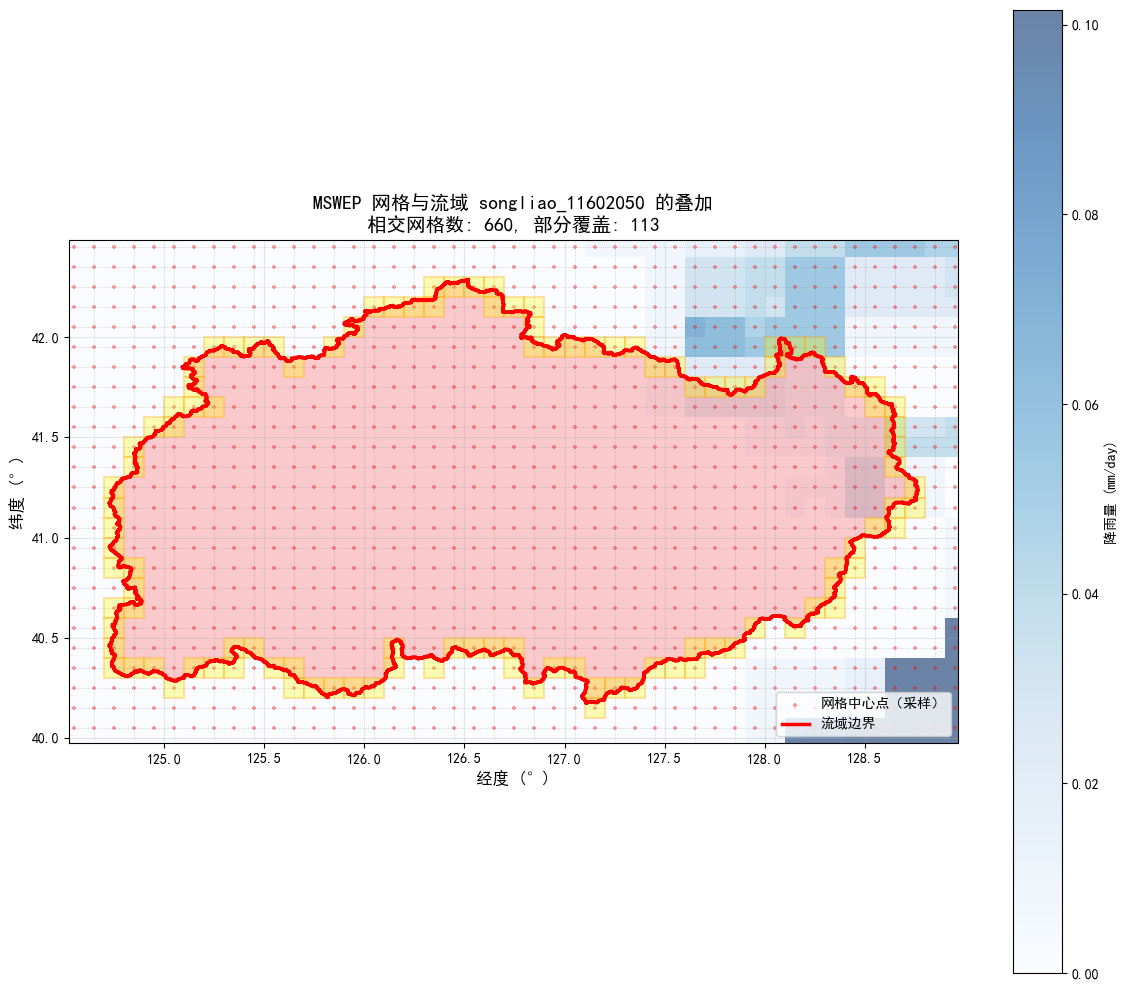


绘制 GFS 网格覆盖示意图...


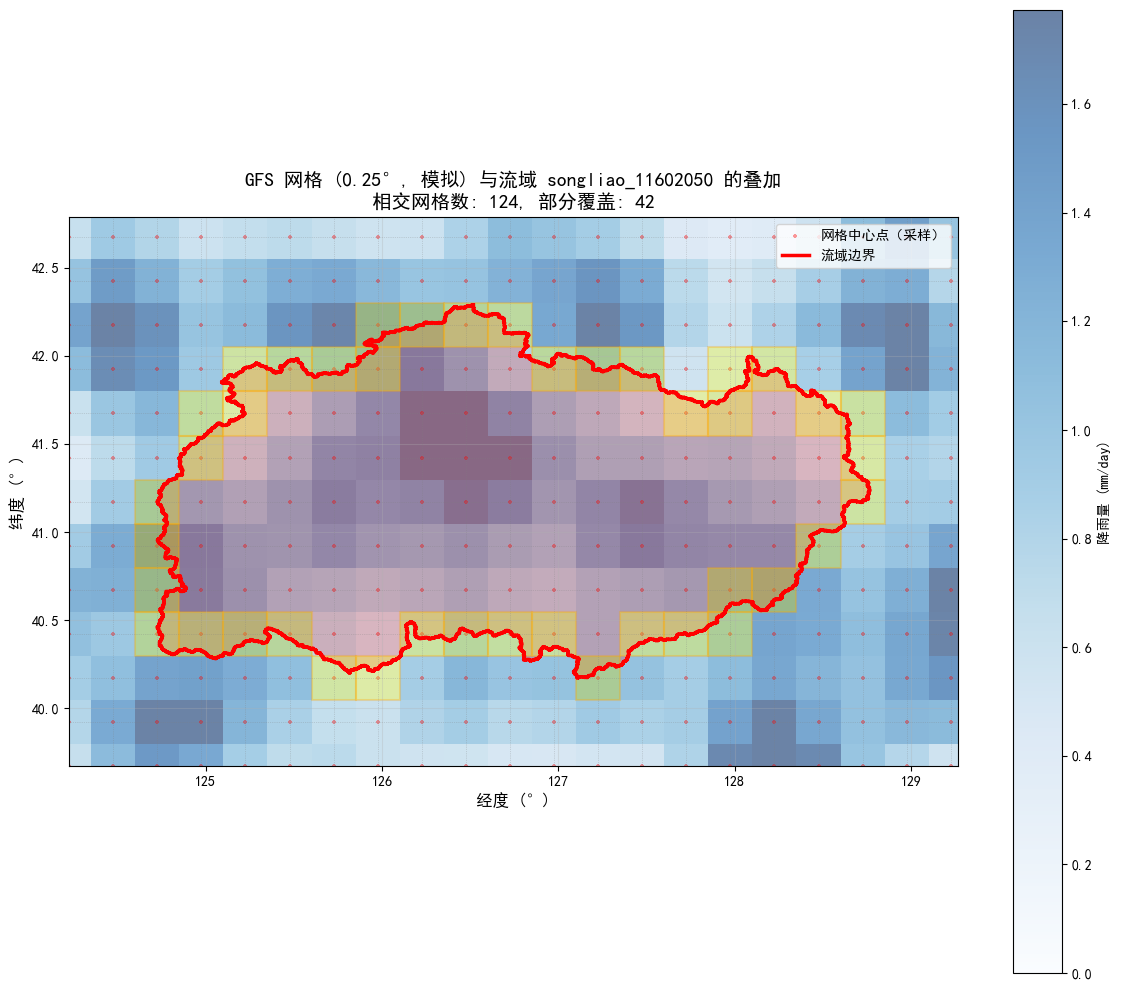

In [ ]:
def plot_basin_grid_overlay(basin_geom, grid_dataset, title):
    """
    绘制流域边界与网格叠加图
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 获取流域边界
    minx, miny, maxx, maxy = basin_geom.bounds
    
    # 获取网格信息
    lats = grid_dataset.lat.values
    lons = grid_dataset.lon.values
    resolution_lat = abs(np.diff(lats).mean())
    resolution_lon = abs(np.diff(lons).mean())
    
    # 选择第一个时间步的降雨数据作为背景
    precip = grid_dataset.precipitation.isel(time=0).values
    
    # 绘制降雨数据
    im = ax.pcolormesh(lons, lats, precip, 
                       cmap='Blues', alpha=0.6, shading='auto',
                       vmin=0, vmax=np.percentile(precip, 95))
    cbar = plt.colorbar(im, ax=ax, label='降雨量 (mm/day)')
    
    # 绘制网格线
    for lat in lats[::max(1, len(lats)//20)]:
        ax.axhline(y=lat, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
    for lon in lons[::max(1, len(lons)//20)]:
        ax.axvline(x=lon, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
    
    # 绘制网格中心点（采样显示）
    sample_rate = max(1, len(lats) // 30)
    lon_grid, lat_grid = np.meshgrid(lons[::sample_rate], lats[::sample_rate])
    ax.scatter(lon_grid.flatten(), lat_grid.flatten(), 
               c='red', s=10, alpha=0.4, marker='+', label='网格中心点（采样）')
    
    # 绘制流域边界
    if basin_geom.geom_type == 'Polygon':
        x, y = basin_geom.exterior.xy
        ax.plot(x, y, 'r-', linewidth=2.5, label='流域边界')
        ax.fill(x, y, color='red', alpha=0.2)
    elif basin_geom.geom_type == 'MultiPolygon':
        for polygon in basin_geom.geoms:
            x, y = polygon.exterior.xy
            ax.plot(x, y, 'r-', linewidth=2.5)
            ax.fill(x, y, color='red', alpha=0.2)
    
    # 统计网格覆盖信息
    grid_count = 0
    partial_count = 0
    
    for lat in lats:
        for lon in lons:
            grid_cell = box(lon - resolution_lon/2, lat - resolution_lat/2,
                           lon + resolution_lon/2, lat + resolution_lat/2)
            
            if grid_cell.intersects(basin_geom):
                intersection = grid_cell.intersection(basin_geom)
                overlap_ratio = intersection.area / grid_cell.area
                
                if overlap_ratio > 0:
                    grid_count += 1
                    if 0.05 < overlap_ratio < 0.95:  # 部分覆盖
                        partial_count += 1
                        # 标注部分覆盖的网格
                        rect = mpatches.Rectangle(
                            (lon - resolution_lon/2, lat - resolution_lat/2),
                            resolution_lon, resolution_lat,
                            linewidth=1.5, edgecolor='orange', 
                            facecolor='yellow', alpha=0.3
                        )
                        ax.add_patch(rect)
    
    ax.set_xlabel('经度 (°)', fontsize=12)
    ax.set_ylabel('纬度 (°)', fontsize=12)
    ax.set_title(f'{title}\n相交网格数: {grid_count}, 部分覆盖: {partial_count}', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 设置显示范围
    margin = max(resolution_lat, resolution_lon) * 2
    ax.set_xlim(minx - margin, maxx + margin)
    ax.set_ylim(miny - margin, maxy + margin)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

# 绘制 MSWEP 网格覆盖
if mswep_data is not None:
    print("绘制 MSWEP 网格覆盖示意图...")
    fig_mswep = plot_basin_grid_overlay(basin_geom, mswep_data, 
                                         f'MSWEP 网格与流域 {basin_id} 的叠加')
    plt.show()

# 绘制 GFS 网格覆盖
print("\n绘制 GFS 网格覆盖示意图...")
fig_gfs = plot_basin_grid_overlay(basin_geom, gfs_data, 
                                   f'GFS 网格 (0.25°, 模拟) 与流域 {basin_id} 的叠加')
plt.show()

## 6. 面积占比法计算流域面平均降雨

**算法原理**:
$$
\bar{P} = \frac{\sum_{i=1}^{n} P_i \cdot A_i}{\sum_{i=1}^{n} A_i}
$$

其中:
- $\bar{P}$ 为流域面平均降雨
- $P_i$ 为第 $i$ 个网格的降雨量
- $A_i$ 为第 $i$ 个网格与流域的交集面积
- $n$ 为与流域相交的网格总数

In [11]:
def calculate_grid_weights(basin_geom, lats, lons):
    """
    计算每个网格单元与流域的交集面积占比（权重）
    
    参数:
        basin_geom: 流域几何对象
        lats: 纬度数组
        lons: 经度数组
    
    返回:
        weights: 权重矩阵 (lat, lon)
        grid_info: 网格信息字典
    """
    resolution_lat = abs(np.diff(lats).mean()) if len(lats) > 1 else 0.1
    resolution_lon = abs(np.diff(lons).mean()) if len(lons) > 1 else 0.1
    
    weights = np.zeros((len(lats), len(lons)))
    grid_info = {
        'total_grids': 0,
        'intersecting_grids': 0,
        'fully_covered_grids': 0,
        'partially_covered_grids': 0
    }
    
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            # 创建网格单元多边形
            grid_cell = box(
                lon - resolution_lon / 2,
                lat - resolution_lat / 2,
                lon + resolution_lon / 2,
                lat + resolution_lat / 2
            )
            
            grid_info['total_grids'] += 1
            
            # 计算交集
            if grid_cell.intersects(basin_geom):
                intersection = grid_cell.intersection(basin_geom)
                intersection_area = intersection.area
                grid_cell_area = grid_cell.area
                
                if intersection_area > 0:
                    weights[i, j] = intersection_area
                    grid_info['intersecting_grids'] += 1
                    
                    # 判断覆盖程度
                    overlap_ratio = intersection_area / grid_cell_area
                    if overlap_ratio > 0.99:
                        grid_info['fully_covered_grids'] += 1
                    else:
                        grid_info['partially_covered_grids'] += 1
    
    # 归一化权重
    total_weight = weights.sum()
    if total_weight > 0:
        weights = weights / total_weight
    
    return weights, grid_info

def compute_basin_mean_precipitation(grid_dataset, basin_geom):
    """
    使用面积占比法计算流域面平均降雨
    
    参数:
        grid_dataset: xarray.Dataset 网格降雨数据
        basin_geom: 流域几何对象
    
    返回:
        basin_mean: pandas.Series 流域面平均降雨时间序列
        weights: 权重矩阵
        grid_info: 网格信息
    """
    lats = grid_dataset.lat.values
    lons = grid_dataset.lon.values
    times = grid_dataset.time.values
    
    # 计算权重
    print("  计算网格权重...")
    weights, grid_info = calculate_grid_weights(basin_geom, lats, lons)
    
    # 计算加权平均
    print("  计算加权平均降雨...")
    basin_mean_values = []
    
    for t in range(len(times)):
        precip = grid_dataset.precipitation.isel(time=t).values
        # 加权平均
        weighted_mean = np.sum(precip * weights)
        basin_mean_values.append(weighted_mean)
    
    # 创建时间序列
    basin_mean = pd.Series(
        basin_mean_values,
        index=pd.DatetimeIndex(times),
        name='basin_mean_precipitation'
    )
    
    return basin_mean, weights, grid_info

# 计算 MSWEP 流域面平均降雨
if mswep_data is not None:
    print("\n计算 MSWEP 流域面平均降雨...")
    start_time = time.time()
    mswep_basin_mean, mswep_weights, mswep_grid_info = compute_basin_mean_precipitation(
        mswep_data, basin_geom
    )
    mswep_calc_time = time.time() - start_time
    
    print(f"\nMSWEP 网格信息:")
    print(f"  总网格数: {mswep_grid_info['total_grids']}")
    print(f"  相交网格数: {mswep_grid_info['intersecting_grids']}")
    print(f"  完全覆盖网格数: {mswep_grid_info['fully_covered_grids']}")
    print(f"  部分覆盖网格数: {mswep_grid_info['partially_covered_grids']}")
    print(f"  计算用时: {mswep_calc_time:.2f} 秒")

# 计算 GFS 流域面平均降雨
print("\n计算 GFS 流域面平均降雨...")
start_time = time.time()
gfs_basin_mean, gfs_weights, gfs_grid_info = compute_basin_mean_precipitation(
    gfs_data, basin_geom
)
gfs_calc_time = time.time() - start_time

print(f"\nGFS 网格信息:")
print(f"  总网格数: {gfs_grid_info['total_grids']}")
print(f"  相交网格数: {gfs_grid_info['intersecting_grids']}")
print(f"  完全覆盖网格数: {gfs_grid_info['fully_covered_grids']}")
print(f"  部分覆盖网格数: {gfs_grid_info['partially_covered_grids']}")
print(f"  计算用时: {gfs_calc_time:.2f} 秒")


计算 MSWEP 流域面平均降雨...
  计算网格权重...
  计算加权平均降雨...

MSWEP 网格信息:
  总网格数: 1581
  相交网格数: 660
  完全覆盖网格数: 512
  部分覆盖网格数: 148
  计算用时: 1.13 秒

计算 GFS 流域面平均降雨...
  计算网格权重...
  计算加权平均降雨...

GFS 网格信息:
  总网格数: 308
  相交网格数: 124
  完全覆盖网格数: 68
  部分覆盖网格数: 56
  计算用时: 0.28 秒


## 7. 展示计算结果

可视化流域面平均降雨时间序列，并进行统计分析。

In [ ]:
# 基本统计
if mswep_data is not None:
    print("=" * 60)
    print("MSWEP 流域面平均降雨统计")
    print("=" * 60)
    print(mswep_basin_mean.describe())
    print(f"\n总降雨量: {mswep_basin_mean.sum():.2f} mm")
    print(f"年均降雨量: {mswep_basin_mean.sum():.2f} mm/year")

print("\n" + "=" * 60)
print("GFS 流域面平均降雨统计 (2024数据)")
print("=" * 60)
print(gfs_basin_mean.describe())
print(f"\n总降雨量: {gfs_basin_mean.sum():.2f} mm")
print(f"年均降雨量: {gfs_basin_mean.sum():.2f} mm/year")

MSWEP 流域面平均降雨统计
count    365.000000
mean       3.184446
std        7.322936
min        0.000000
25%        0.060390
50%        0.590739
75%        3.527786
max       77.811127
Name: basin_mean_precipitation, dtype: float64

总降雨量: 1162.32 mm
年均降雨量: 1162.32 mm/year

GFS 流域面平均降雨统计 (模拟数据)
count    365.000000
mean       0.987860
std        0.133047
min        0.665166
25%        0.898457
50%        0.986839
75%        1.069562
max        1.503531
Name: basin_mean_precipitation, dtype: float64

总降雨量: 360.57 mm
年均降雨量: 360.57 mm/year


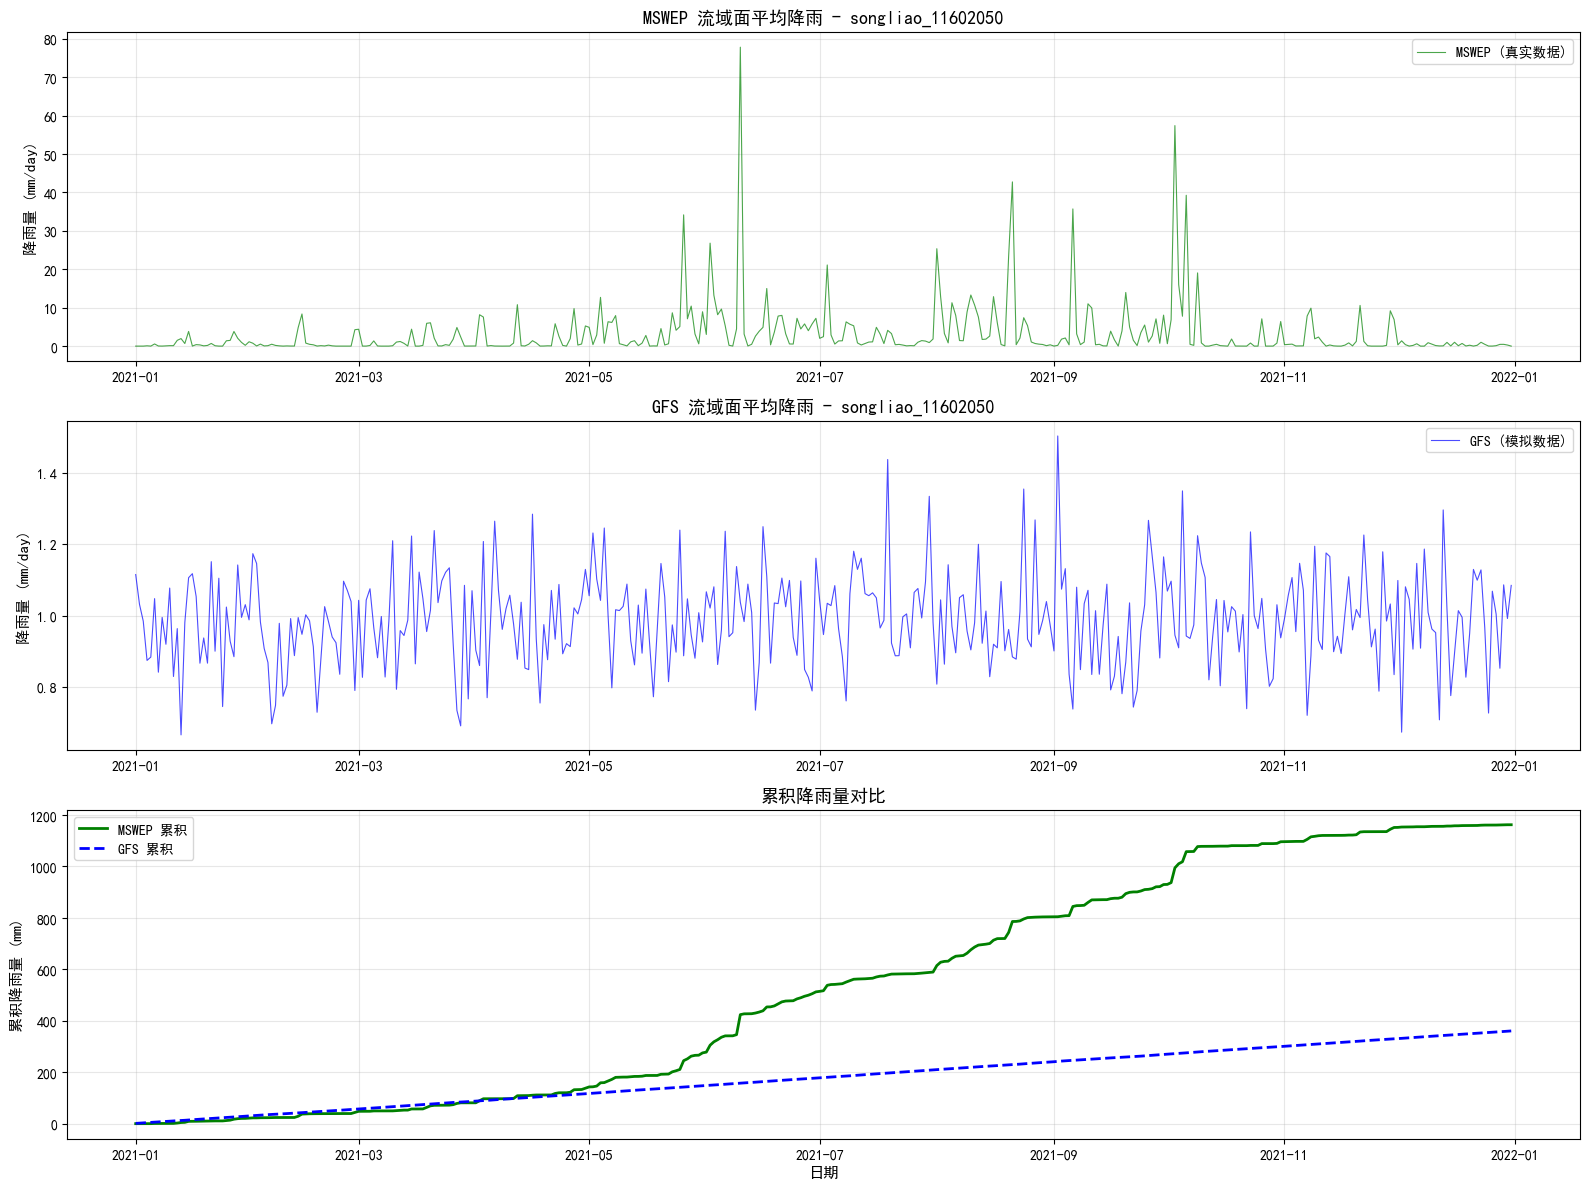

In [ ]:
# 绘制时间序列对比图
if mswep_data is not None:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # 子图1: MSWEP 时间序列
    ax1 = axes[0]
    ax1.plot(mswep_basin_mean.index, mswep_basin_mean.values, 
             linewidth=0.8, color='green', alpha=0.7, label='MSWEP (真实数据)')
    ax1.set_ylabel('降雨量 (mm/day)', fontsize=11)
    ax1.set_title(f'MSWEP 流域面平均降雨 - {basin_id}', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')
    
    # 子图2: GFS 时间序列
    ax2 = axes[1]
    ax2.plot(gfs_basin_mean.index, gfs_basin_mean.values, 
             linewidth=0.8, color='blue', alpha=0.7, label='GFS (2024数据)')
    ax2.set_ylabel('降雨量 (mm/day)', fontsize=11)
    ax2.set_title(f'GFS 流域面平均降雨 - {basin_id}', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    # 子图3: 累积降雨对比
    ax3 = axes[2]
    mswep_cumsum = mswep_basin_mean.cumsum()
    gfs_cumsum = gfs_basin_mean.cumsum()
    ax3.plot(mswep_cumsum.index, mswep_cumsum.values, 
             linewidth=2, color='green', label='MSWEP 累积')
    ax3.plot(gfs_cumsum.index, gfs_cumsum.values, 
             linewidth=2, color='blue', label='GFS 累积', linestyle='--')
    ax3.set_xlabel('日期', fontsize=11)
    ax3.set_ylabel('累积降雨量 (mm)', fontsize=11)
    ax3.set_title('累积降雨量对比', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()
else:
    # 只有 GFS
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(gfs_basin_mean.index, gfs_basin_mean.values, 
            linewidth=1, color='blue', alpha=0.7, label='GFS (2024)')
    ax.set_ylabel('降雨量 (mm/day)', fontsize=11)
    ax.set_xlabel('日期', fontsize=11)
    ax.set_title(f'GFS 流域面平均降雨 - {basin_id}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

## 8. 统计汇总

汇总本次计算的关键信息。

In [ ]:
# 创建统计汇总表
if mswep_data is not None:
    summary = {
        '数据源': ['MSWEP (真实)', 'GFS (2024)'],
        '数据类型': ['真实数据', '2024数据'],
        '空间分辨率': [f"~{abs(mswep_data.lat.diff('lat').mean().values):.3f}°", '0.25°'],
        '时间分辨率': ['日', '日'],
        '时间点数': [len(mswep_basin_mean), len(gfs_basin_mean)],
        '相交网格数': [mswep_grid_info['intersecting_grids'], 
                      gfs_grid_info['intersecting_grids']],
        '年总降雨量(mm)': [f"{mswep_basin_mean.sum():.2f}", 
                          f"{gfs_basin_mean.sum():.2f}"],
        '日均降雨量': [f"{mswep_basin_mean.mean():.3f} mm/day", 
                      f"{gfs_basin_mean.mean():.3f} mm/day"],
        '最大日降雨': [f"{mswep_basin_mean.max():.2f} mm", 
                      f"{gfs_basin_mean.max():.2f} mm"],
        '计算用时(秒)': [f"{mswep_calc_time:.2f}", f"{gfs_calc_time:.2f}"]
    }
else:
    summary = {
        '数据源': ['GFS (模拟)'],
        '数据类型': ['2024数据'],
        '空间分辨率': ['0.25°'],
        '时间分辨率': ['日'],
        '时间点数': [len(gfs_basin_mean)],
        '相交网格数': [gfs_grid_info['intersecting_grids']],
        '年总降雨量(mm)': [f"{gfs_basin_mean.sum():.2f}"],
        '日均降雨量': [f"{gfs_basin_mean.mean():.3f} mm/day"],
        '最大日降雨': [f"{gfs_basin_mean.max():.2f} mm"],
        '计算用时(秒)': [f"{gfs_calc_time:.2f}"]
    }

summary_df = pd.DataFrame(summary)

print("\n" + "=" * 80)
print("计算统计汇总")
print("=" * 80)
print(f"\n流域信息:")
print(f"  流域ID: {basin_id}")
print(f"  流域面积: {basin_area:.2f} km²")
print(f"\n时间范围:")
print(f"  年份: 2021")
print(f"  开始日期: {gfs_basin_mean.index[0].strftime('%Y-%m-%d')}")
print(f"  结束日期: {gfs_basin_mean.index[-1].strftime('%Y-%m-%d')}")
print(f"  持续时长: {len(gfs_basin_mean)} 天")
print(f"\n数据对比:")
print(summary_df.to_string(index=False))
print("\n" + "=" * 80)

## 9. 保存结果

将计算结果保存为 CSV 和 NetCDF 格式。

In [15]:
# 创建输出目录
output_dir = f"results/{basin_id}"
os.makedirs(output_dir, exist_ok=True)

# 保存 MSWEP 结果
if mswep_data is not None:
    mswep_basin_mean.to_csv(f"{output_dir}/mswep_basin_mean_2021.csv", 
                            header=['precipitation'])
    
    mswep_result_ds = xr.Dataset({
        'precipitation': (['time'], mswep_basin_mean.values)
    }, coords={
        'time': mswep_basin_mean.index
    }, attrs={
        'basin_id': basin_id,
        'basin_area_km2': basin_area,
        'data_source': 'MSWEP',
        'data_type': 'Real Data',
        'resolution': f"{abs(mswep_data.lat.diff('lat').mean().values):.3f} degrees",
        'time_frequency': 'daily',
        'method': 'Grid Area-Weighted Method',
        'intersecting_grids': mswep_grid_info['intersecting_grids'],
        'year': 2021
    })
    mswep_result_ds.to_netcdf(f"{output_dir}/mswep_basin_mean_2021.nc")

# 保存 GFS 结果
gfs_basin_mean.to_csv(f"{output_dir}/gfs_basin_mean_2021_simulated.csv", 
                      header=['precipitation'])

gfs_result_ds = xr.Dataset({
    'precipitation': (['time'], gfs_basin_mean.values)
}, coords={
    'time': gfs_basin_mean.index
}, attrs={
    'basin_id': basin_id,
    'basin_area_km2': basin_area,
    'data_source': 'GFS',
    'data_type': 'Simulated Data',
    'resolution': '0.25 degrees',
    'time_frequency': 'daily',
    'method': 'Grid Area-Weighted Method',
    'intersecting_grids': gfs_grid_info['intersecting_grids'],
    'year': 2021
})
gfs_result_ds.to_netcdf(f"{output_dir}/gfs_basin_mean_2021_simulated.nc")

# 保存统计汇总
summary_df.to_csv(f"{output_dir}/calculation_summary_2021.csv", index=False)

print(f"\n结果已保存到: {output_dir}")
print(f"\n文件列表:")
for file in sorted(os.listdir(output_dir)):
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024  # KB
    print(f"  - {file} ({file_size:.2f} KB)")


结果已保存到: results/songliao_11602050

文件列表:
  - calculation_summary_2021.csv (0.31 KB)
  - gfs_basin_mean_2021_simulated.csv (10.63 KB)
  - gfs_basin_mean_2021_simulated.nc (14.40 KB)
  - mswep_basin_mean_2021.csv (10.81 KB)
  - mswep_basin_mean_2021.nc (14.40 KB)
